In [1]:
!pip install -q sentence-transformers

Found existing installation: torchcodec 0.10.0+cu128
Uninstalling torchcodec-0.10.0+cu128:
  Successfully uninstalled torchcodec-0.10.0+cu128


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


              Strategy  Acc@1 (%)  Acc@3 (%)  Acc@5 (%)  P@3 (%)  P@5 (%)  F1@3 (%)  F1@5 (%)   MRR  NDCG@3  NDCG@5   MAP  Total Chunks
Structural (Overlap=0)      66.67      80.00      86.67    26.67    17.33     40.00     28.89 0.741   0.745   0.773 0.741           341
 Window (S=600, O=100)      31.11      37.78      42.22    12.59     8.44     18.89     14.07 0.351   0.350   0.368 0.351           225
 Window (S=600, O=200)      17.78      35.56      44.44    11.85     8.89     17.78     14.81 0.278   0.284   0.319 0.278           281
Window (S=1000, O=300)      35.56      55.56      64.44    18.52    12.89     27.78     21.48 0.467   0.476   0.511 0.467           161


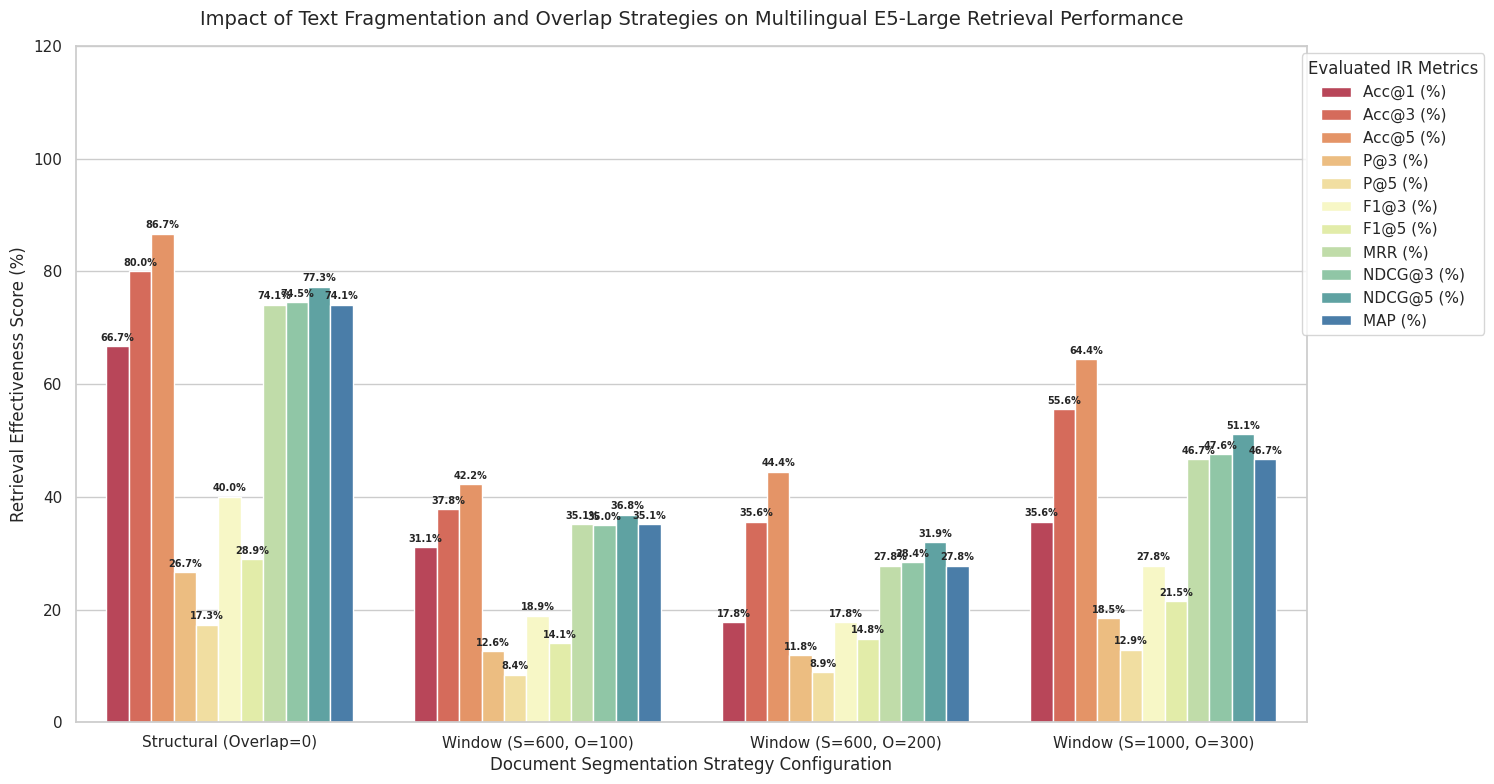

In [3]:
import json
import time
import torch
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util

def load_test_dataset(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_structural_chunks(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        parsed_data = json.load(f)
    return ["passage: " + str(item["text"]).strip() for item in parsed_data if item.get("text") and len(str(item["text"])) > 5]

def generate_sliding_window_chunks(json_path, chunk_size=600, overlap=150):
    with open(json_path, 'r', encoding='utf-8') as f:
        parsed_data = json.load(f)
    full_text = " ".join([str(item["text"]).strip() for item in parsed_data if item.get("text")])
    chunks = []
    start = 0
    while start < len(full_text):
        end = start + chunk_size
        chunks.append("passage: " + full_text[start:end].strip())
        start += (chunk_size - overlap)
    return chunks

def calculate_ndcg(rank, max_k=5):
    if 1 <= rank <= max_k:
        return 1.0 / np.log2(rank + 1)
    return 0.0

def evaluate_strategy(corpus_texts, test_dataset, model, device):
    corpus_embeddings = model.encode(
        corpus_texts,
        convert_to_tensor=True,
        normalize_embeddings=True,
        batch_size=16,
        show_progress_bar=False
    )

    hits_at_1 = 0
    hits_at_3 = 0
    hits_at_5 = 0
    mrr_sum = 0.0
    ndcg_3_sum = 0.0
    ndcg_5_sum = 0.0
    map_sum = 0.0
    p_3_sum = 0.0
    p_5_sum = 0.0
    f1_3_sum = 0.0
    f1_5_sum = 0.0

    for item in test_dataset:
        query_text = "query: " + item["query"]
        query_emb = model.encode(query_text, convert_to_tensor=True, normalize_embeddings=True)
        cos_scores = util.cos_sim(query_emb, corpus_embeddings)[0]

        k_val = min(5, len(corpus_texts))
        top_k = torch.topk(cos_scores, k=k_val)
        found_texts = [corpus_texts[idx] for idx in top_k.indices.tolist()]

        target_clean = item["target"].strip()

        rank = -1
        for idx, text in enumerate(found_texts):
            clean_text = text.replace("passage: ", "").strip()
            if clean_text == target_clean or target_clean in clean_text or clean_text in target_clean:
                rank = idx + 1
                break

        if rank == 1:
            hits_at_1 += 1
        if rank in [1, 2, 3]:
            hits_at_3 += 1
        if rank in [1, 2, 3, 4, 5]:
            hits_at_5 += 1

        if rank != -1:
            mrr_sum += 1.0 / rank
            map_sum += 1.0 / rank
            if rank <= 3:
                ndcg_3_sum += calculate_ndcg(rank, max_k=3)
            ndcg_5_sum += calculate_ndcg(rank, max_k=5)

        p_3 = 1.0 / 3.0 if (1 <= rank <= 3) else 0.0
        p_5 = 1.0 / 5.0 if (1 <= rank <= 5) else 0.0
        p_3_sum += p_3
        p_5_sum += p_5

        f1_3_sum += (2 * p_3 * 1.0) / (p_3 + 1.0) if p_3 > 0 else 0.0
        f1_5_sum += (2 * p_5 * 1.0) / (p_5 + 1.0) if p_5 > 0 else 0.0

    total = len(test_dataset)
    return {
        "Acc@1 (%)": round((hits_at_1 / total) * 100, 2),
        "Acc@3 (%)": round((hits_at_3 / total) * 100, 2),
        "Acc@5 (%)": round((hits_at_5 / total) * 100, 2),
        "P@3 (%)": round((p_3_sum / total) * 100, 2),
        "P@5 (%)": round((p_5_sum / total) * 100, 2),
        "F1@3 (%)": round((f1_3_sum / total) * 100, 2),
        "F1@5 (%)": round((f1_5_sum / total) * 100, 2),
        "MRR": round(mrr_sum / total, 3),
        "NDCG@3": round(ndcg_3_sum / total, 3),
        "NDCG@5": round(ndcg_5_sum / total, 3),
        "MAP": round(map_sum / total, 3),
        "Total Chunks": len(corpus_texts)
    }

if __name__ == "__main__":
    json_path = "/content/parsed_pdf.json"
    test_dataset_path = "/content/test_dataset.json"
    device = "cuda" if torch.cuda.is_available() else "cpu"

    test_dataset = load_test_dataset(test_dataset_path)

    model = SentenceTransformer("intfloat/multilingual-e5-large", device=device)
    model.max_seq_length = 512

    results = []

    struct_corpus = load_structural_chunks(json_path)
    res_struct = evaluate_strategy(struct_corpus, test_dataset, model, device)
    res_struct["Strategy"] = "Structural (Overlap=0)"
    results.append(res_struct)

    overlap_configs = [
        {"size": 600, "overlap": 100},
        {"size": 600, "overlap": 200},
        {"size": 1000, "overlap": 300}
    ]

    for conf in overlap_configs:
        name = f"Window (S={conf['size']}, O={conf['overlap']})"
        sliding_corpus = generate_sliding_window_chunks(json_path, chunk_size=conf["size"], overlap=conf["overlap"])
        res_sliding = evaluate_strategy(sliding_corpus, test_dataset, model, device)
        res_sliding["Strategy"] = name
        results.append(res_sliding)

    columns = [
        "Strategy", "Acc@1 (%)", "Acc@3 (%)", "Acc@5 (%)",
        "P@3 (%)", "P@5 (%)", "F1@3 (%)", "F1@5 (%)",
        "MRR", "NDCG@3", "NDCG@5", "MAP", "Total Chunks"
    ]
    df = pd.DataFrame(results)[columns]
    print(df.to_string(index=False))

    plt.figure(figsize=(15, 8))
    sns.set_theme(style="whitegrid")

    metric_cols = ["Acc@1 (%)", "Acc@3 (%)", "Acc@5 (%)", "P@3 (%)", "P@5 (%)", "F1@3 (%)", "F1@5 (%)", "MRR", "NDCG@3", "NDCG@5", "MAP"]
    df_melted = df.melt(id_vars=["Strategy"], value_vars=metric_cols, var_name="Metric", value_name="Value")

    mask_normalized = df_melted["Metric"].isin(["MRR", "NDCG@3", "NDCG@5", "MAP"])
    df_melted.loc[mask_normalized, "Value"] *= 100
    df_melted["Metric"] = df_melted["Metric"].replace({
        "MRR": "MRR (%)",
        "NDCG@3": "NDCG@3 (%)",
        "NDCG@5": "NDCG@5 (%)",
        "MAP": "MAP (%)"
    })

    ax = sns.barplot(data=df_melted, x="Strategy", y="Value", hue="Metric", palette="Spectral")

    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(
                f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 6),
                textcoords='offset points',
                fontsize=7,
                weight='bold'
            )

    plt.title("Impact of Text Fragmentation and Overlap Strategies on Multilingual E5-Large Retrieval Performance", fontsize=14, pad=15)
    plt.ylabel("Retrieval Effectiveness Score (%)", fontsize=12)
    plt.xlabel("Document Segmentation Strategy Configuration", fontsize=12)
    plt.ylim(0, 120)
    plt.xticks(fontsize=11)
    plt.legend(title="Evaluated IR Metrics", loc="upper right", frameon=True, bbox_to_anchor=(1.15, 1))
    plt.tight_layout()

    os.makedirs("/content/plots", exist_ok=True)
    plot_path = "/content/plots/chunking_metrics_compare_e5.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')